In [1]:
import os  # OS operations like file handling
import torch
import random  # Random number generation
import pandas as pd  # Data manipulation 
from PIL import Image  # Image processing
import cv2  # Computer vision tasks
from IPython.display import Video  # Display videos in Jupyter notebooks
import numpy as np  # Numerical computations
import matplotlib.pyplot as plt  # Plotting graphs and visualizations
import seaborn as sns  # Statistical data visualizations
sns.set(style='darkgrid')
import pathlib  # File system paths handling
import glob  # File pattern matching (e.g., search for files)
from tqdm.notebook import trange, tqdm  # Progress bars in notebooks
import warnings  # Manage warning messages
warnings.filterwarnings('ignore')
from ultralytics import YOLO 

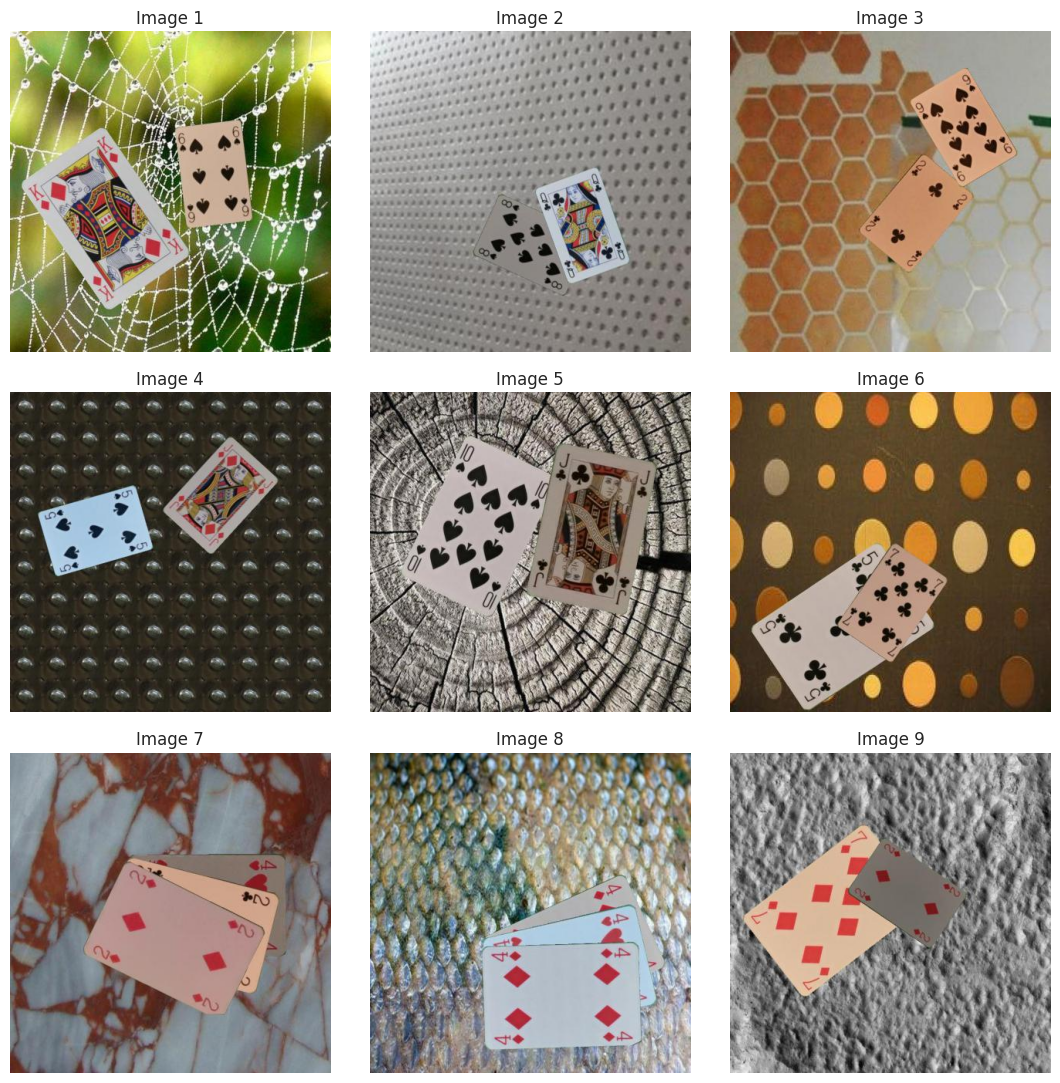

In [2]:
train_path = "./train/images"
val_path   = "./valid/images"
training_images_dir = train_path
num_samples = 9
image_files = os.listdir(training_images_dir)
rand_images = random.sample(image_files, num_samples)

fig, axes = plt.subplots(3, 3, figsize=(11, 11))

for i in range(num_samples):
    image = rand_images[i]
    ax = axes[i // 3, i % 3]
    ax.imshow(plt.imread(os.path.join(training_images_dir, image)))
    ax.set_title(f'Image {i+1}')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [3]:
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "1" 
print(f"Total GPUs visible: {torch.cuda.device_count()}")
print(f"Current GPU: {torch.cuda.get_device_name(0)}")

Total GPUs visible: 1
Current GPU: Quadro RTX 6000


In [4]:
Final_model = YOLO('yolov5nu.pt')

Result_Final_model = Final_model.train(
    data="data.yaml",
    epochs=3,
    batch=16,        
    optimizer='auto',
    device=0,       
    cache=False,
    imgsz=416,
    hsv_v=0.4,
    degrees=180,
    scale=0.6,
    shear=10,
    perspective=0.001
)

Ultralytics 8.4.11 🚀 Python-3.11.2 torch-2.10.0+cu128 CUDA:0 (Quadro RTX 6000, 24023MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=180, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov5nu.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train24, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.001, plots=T

2026-02-03 17:05:28,084	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Overriding model.yaml nc=80 with nc=52

                   from  n    params  module                                       arguments                     
  0                  -1  1      1760  ultralytics.nn.modules.conv.Conv             [3, 16, 6, 2, 2]              
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      4800  ultralytics.nn.modules.block.C3              [32, 32, 1]                   
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     29184  ultralytics.nn.modules.block.C3              [64, 64, 2]                   
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  3    156928  ultralytics.nn.modules.block.C3              [128, 128, 3]                 
  7                  -1  1    295424  ultralytic

In [5]:
def display_images(post_training_files_path, image_files):

    for image_file in image_files:
        image_path = os.path.join(post_training_files_path, image_file)
        img = cv2.imread(image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.figure(figsize=(20, 10), dpi=120)
        plt.imshow(img)
        plt.axis('off')
        plt.show()

In [6]:
best_model_path = '/work/csse463/202620/03/runs/detect/train20/weights/best.pt'
model = YOLO(best_model_path)

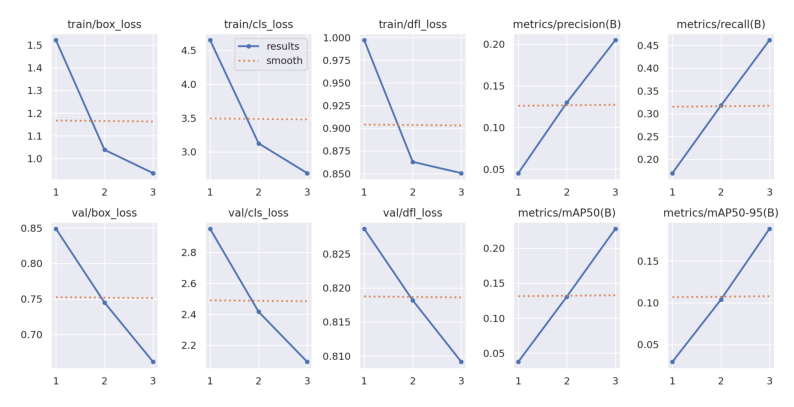

In [7]:
results_img_path = '/work/csse463/202620/03/runs/detect/train20/results.png'

if os.path.exists(results_img_path):
    img = Image.open(results_img_path)
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

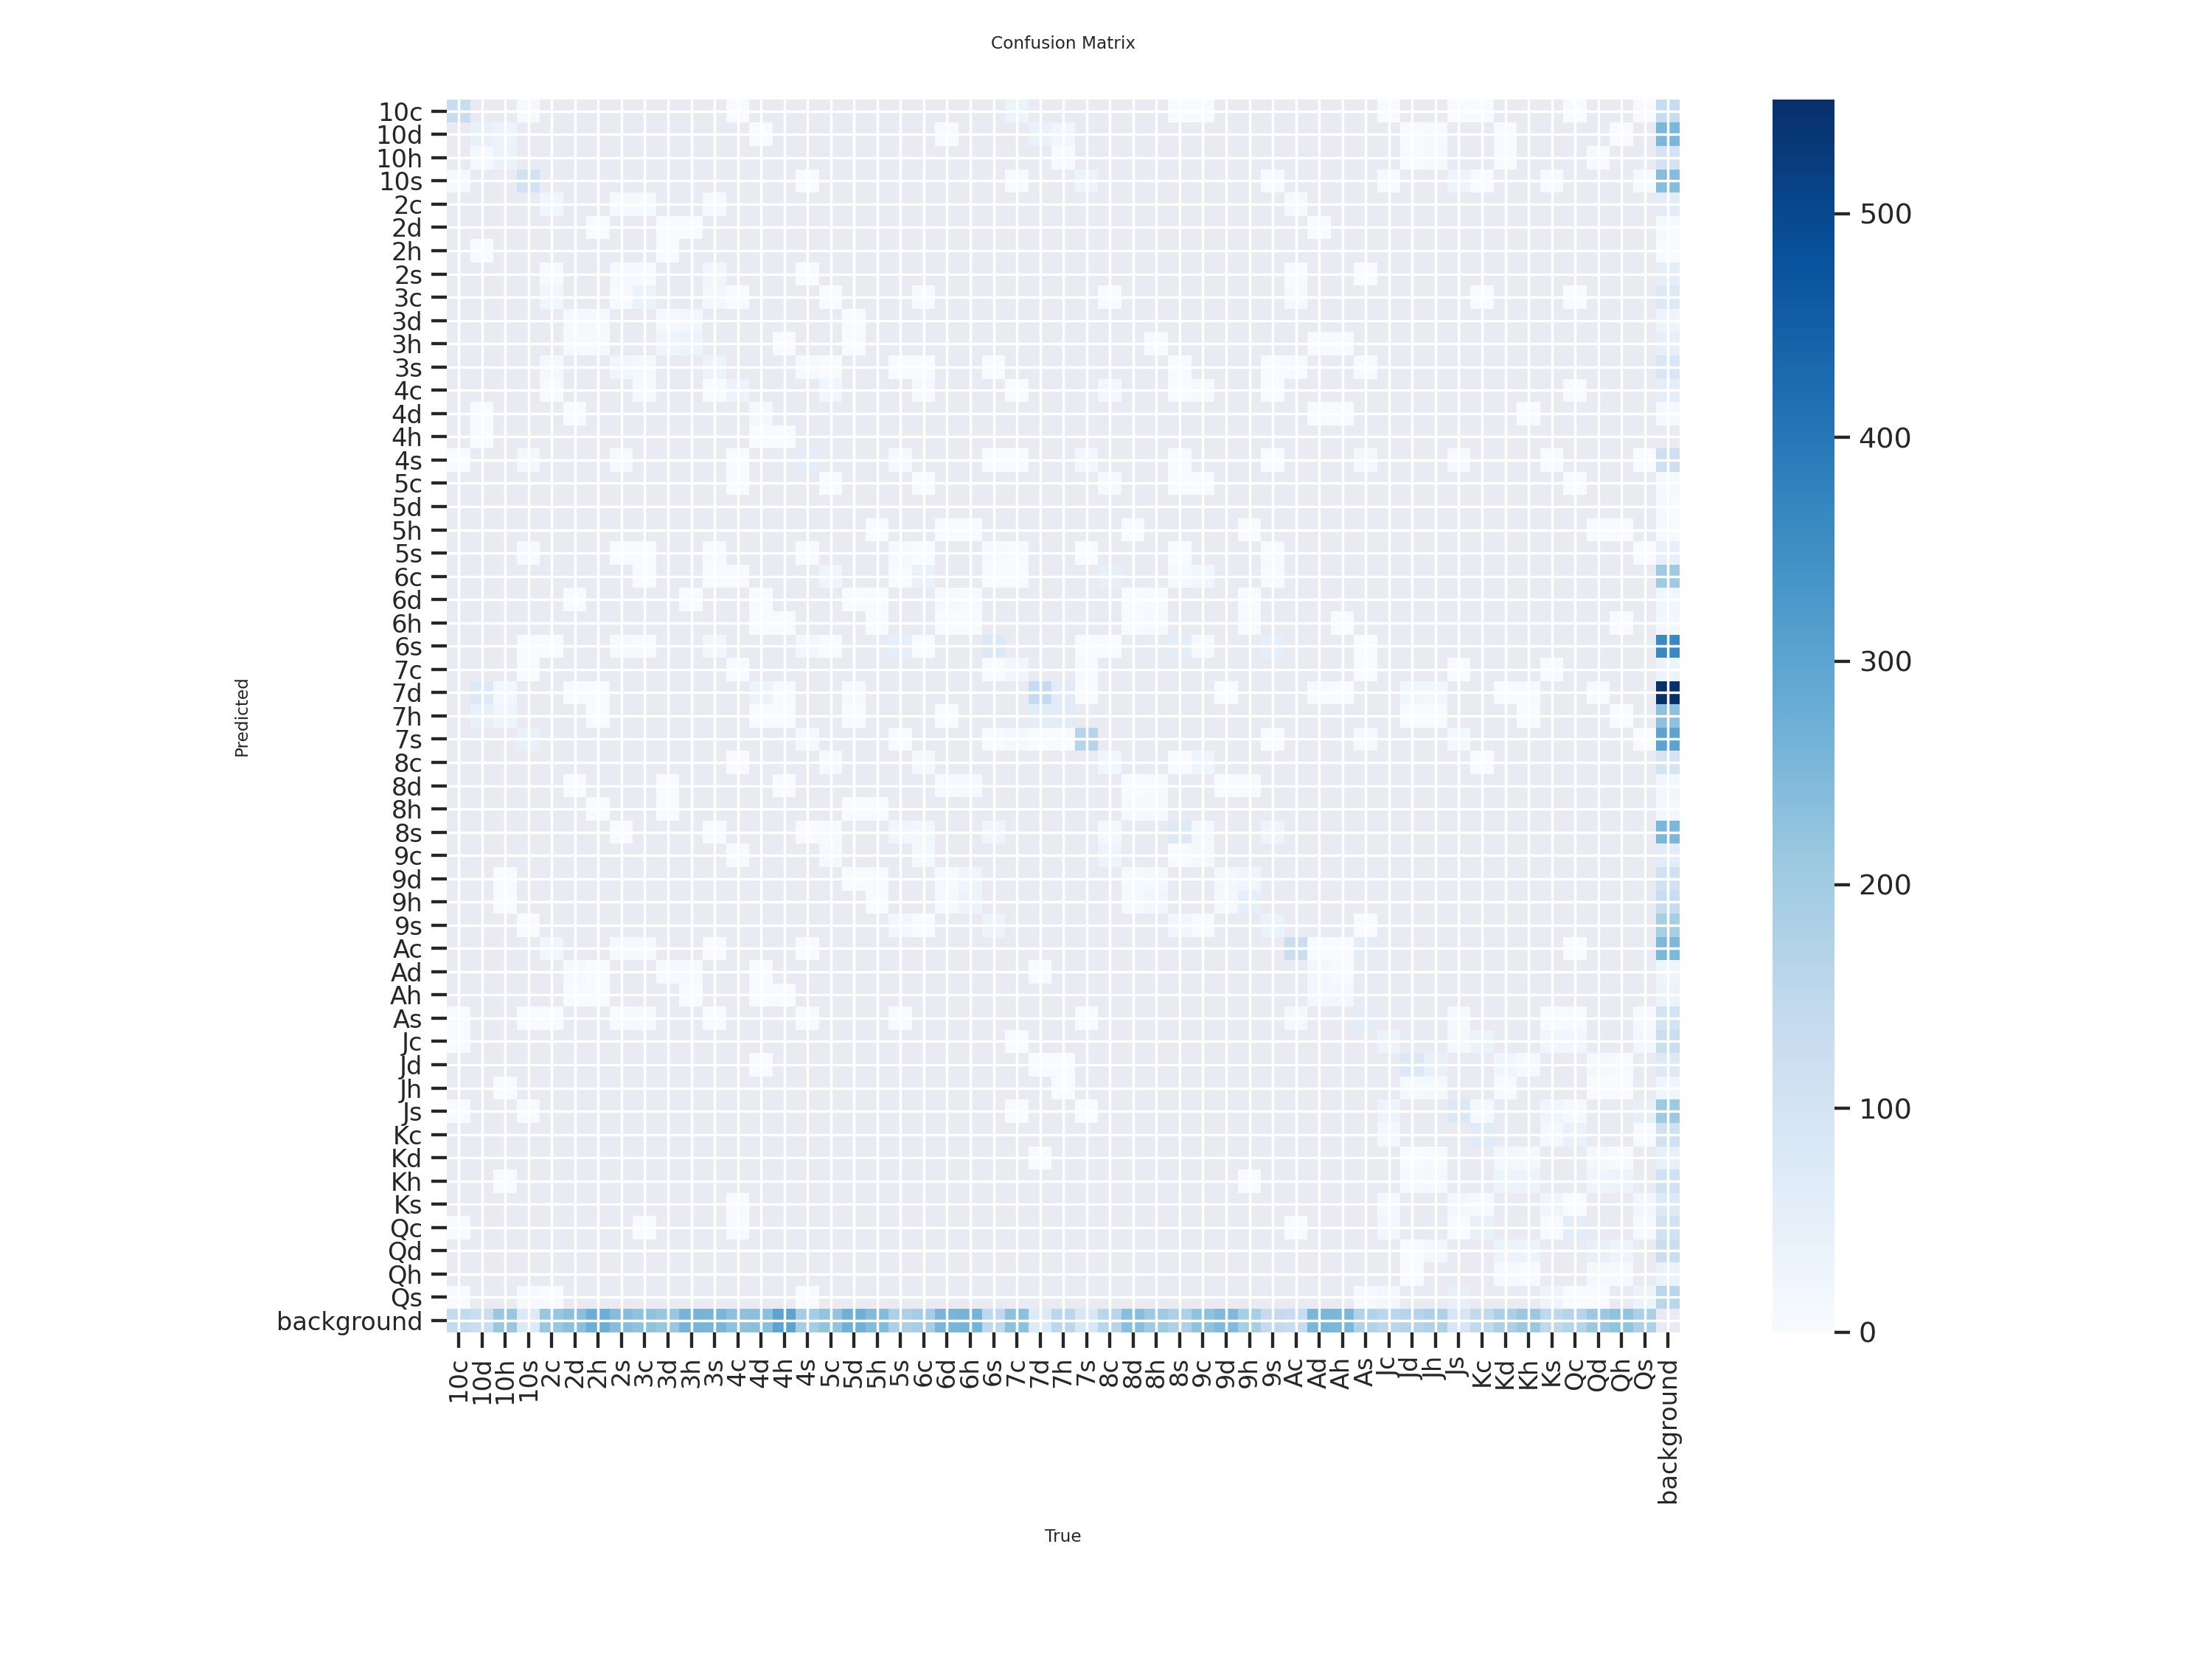

In [8]:
conf_matrix_path = '/work/csse463/202620/03/runs/detect/train20/confusion_matrix.png'
display(Image.open(conf_matrix_path))

In [9]:
Result_Final_model = pd.read_csv('/work/csse463/202620/03/runs/detect/train20/results.csv')
Result_Final_model.tail(10)

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,176.955,1.52215,4.65101,0.99707,0.04517,0.16984,0.03767,0.02937,0.84889,2.95274,0.82868,0.000060,0.000060,0.000060
1,2,319.635,1.03839,3.12588,0.86298,0.12985,0.31802,0.13076,0.10385,0.74496,2.41598,0.81818,0.000080,0.000080,0.000080
2,3,467.519,0.93540,2.68650,0.85057,0.20490,0.46139,0.22766,0.18859,0.66141,2.09282,0.80916,0.000061,0.000061,0.000061


In [10]:
test_path = './test/images'
model = YOLO('/work/csse463/202620/03/runs/detect/train20/weights/best.pt')
results = model.predict(source=test_path, save=True, imgsz=416, conf=0.25)
print(f"Visual results saved to: {results[0].save_dir}")


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/2000 /work/csse463/202620/03/test/images/000246247_jpg.rf.fb915aef7c063ce2ac971f8de0d8b2c1.jpg: 416x416 (no detections), 40.8ms
image 2/2000 /work/csse463/202620/03/test/images/000355142_jpg.rf.7e5eff691d035112dd4b5021fe38a46c.jpg: 416x416 1 3s, 2 4ss, 1 7s, 23.3ms
image 3/2000 /work/csse463/202620/03/test/images/001761433_jpg.rf.1a4a563beb6d588841bd8bd3a50c083b.jpg: 416x416 (no detections), 23.9ms
image 4/2000 /work/csse463/202620/03/test/images

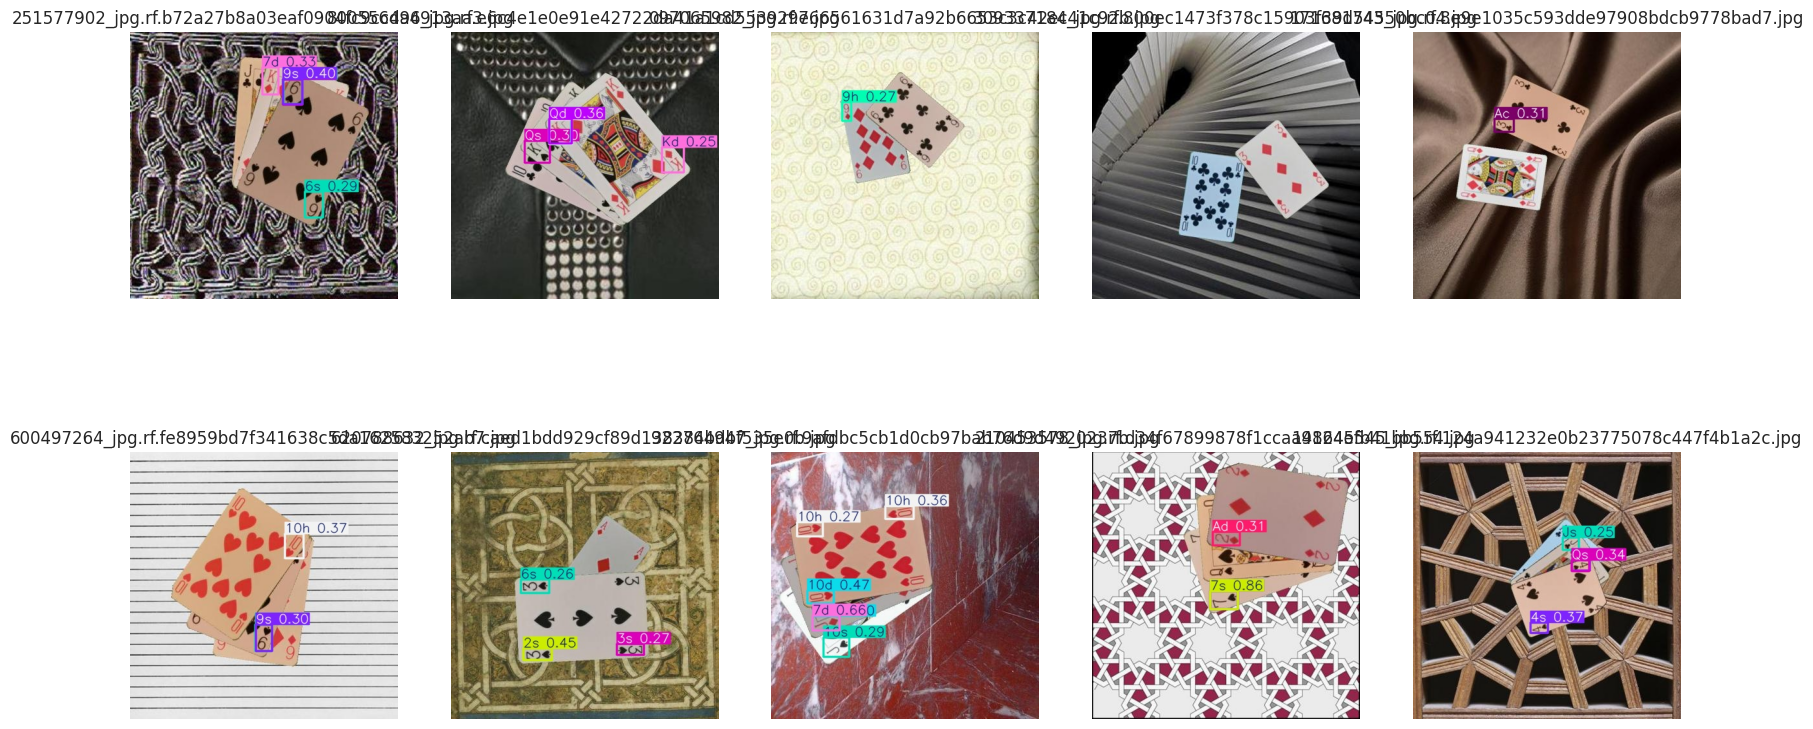

In [11]:
predict_dir = '/work/csse463/202620/03/runs/detect/predict'

# Get list of all images in that folder
all_images = [f for f in os.listdir(predict_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]

# Pick 3 random images
samples = random.sample(all_images, min(10, len(all_images)))

# Plot them
plt.figure(figsize=(20, 10))
for i, img_name in enumerate(samples):
    img_path = os.path.join(predict_dir, img_name)
    img = Image.open(img_path)
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(img_name)
    plt.axis('off')

plt.show()

In [12]:
model = YOLO('/work/csse463/202620/03/runs/detect/train20/weights/best.pt')

# Run validation on the test split
stats = model.val(split='test')

# Print the "Big Three" stats
print(f"Overall Precision: {stats.results_dict['metrics/precision(B)']:.3f}")
print(f"Overall Recall:    {stats.results_dict['metrics/recall(B)']:.3f}")
print(f"Overall mAP50:     {stats.results_dict['metrics/mAP50(B)']:.3f}")

Ultralytics 8.4.11 🚀 Python-3.11.2 torch-2.10.0+cu128 CUDA:0 (Quadro RTX 6000, 24023MiB)


YOLOv5n summary (fused): 85 layers, 2,513,084 parameters, 0 gradients, 7.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 37.1±9.6 MB/s, size: 38.2 KB)
val: Scanning /work/csse463/202620/03/test/labels.cache... 2000 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2000/2000 289.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 125/125 5.3it/s 23.6s0.1ss
                   all       2000       7588      0.202      0.471      0.234      0.195
                   10c         89        137      0.276      0.693      0.418      0.337
                   10d        103        170      0.216      0.641      0.285      0.232
                   10h        100        149      0.208      0.517      0.249      0.197
                   10s         96        151      0.254      0.821      0.388      0.315
                    2c         90        139      0.206       0.36      0.203      0.174
                    2d     